In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

df = pd.read_csv("data/training_data.csv")
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

(1872, 17)
block_id                     str
estate                       str
year                       int64
month                      int64
zone                         str
elevation_m                int64
area_hectares            float64
soil_type                    str
growth_stage                 str
bush_age_yrs               int64
rainfall_mm              float64
avg_temp_c               float64
avg_humidity_pct         float64
days_since_fertilized      int64
last_fertilizer_type         str
yield_last_month         float64
yield_kg                 float64
dtype: object
block_id                  0
estate                    0
year                      0
month                     0
zone                      0
elevation_m               0
area_hectares             0
soil_type                 0
growth_stage              0
bush_age_yrs              0
rainfall_mm               0
avg_temp_c                0
avg_humidity_pct          0
days_since_fertilized     0
last_fertilizer_type  

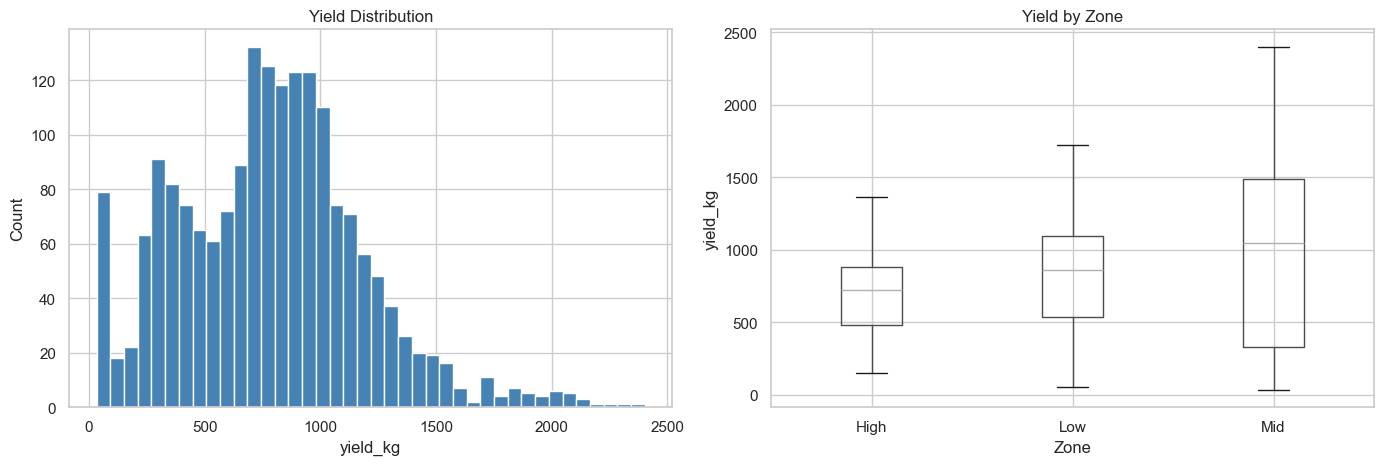

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["yield_kg"], bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Yield Distribution")
axes[0].set_xlabel("yield_kg")
axes[0].set_ylabel("Count")

# Boxplot by zone
df.boxplot(column="yield_kg", by="zone", ax=axes[1])
axes[1].set_title("Yield by Zone")
axes[1].set_xlabel("Zone")
axes[1].set_ylabel("yield_kg")
plt.suptitle("")

plt.tight_layout()
plt.show()

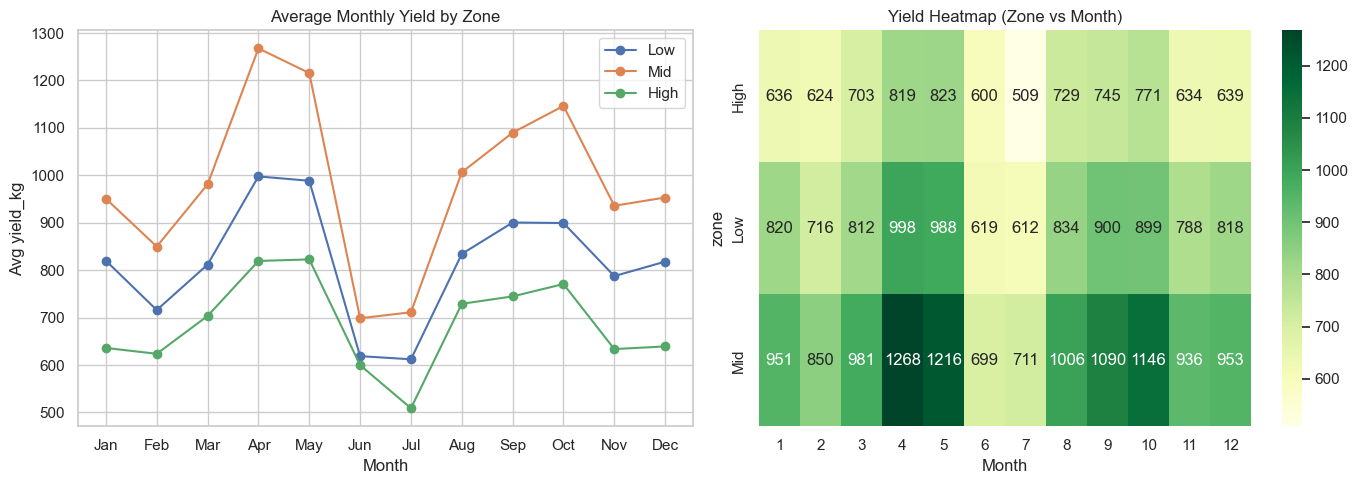

In [14]:
monthly_avg = df.groupby(["month", "zone"])["yield_kg"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot: avg yield per month by zone
for zone in ["Low", "Mid", "High"]:
    data = monthly_avg[monthly_avg["zone"] == zone]
    axes[0].plot(data["month"], data["yield_kg"], marker="o", label=zone)

axes[0].set_title("Average Monthly Yield by Zone")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg yield_kg")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
axes[0].legend()

# Heatmap: month vs zone
pivot = monthly_avg.pivot(index="zone", columns="month", values="yield_kg")
sns.heatmap(pivot, ax=axes[1], cmap="YlGn", annot=True, fmt=".0f")
axes[1].set_title("Yield Heatmap (Zone vs Month)")
axes[1].set_xlabel("Month")

plt.tight_layout()
plt.show()

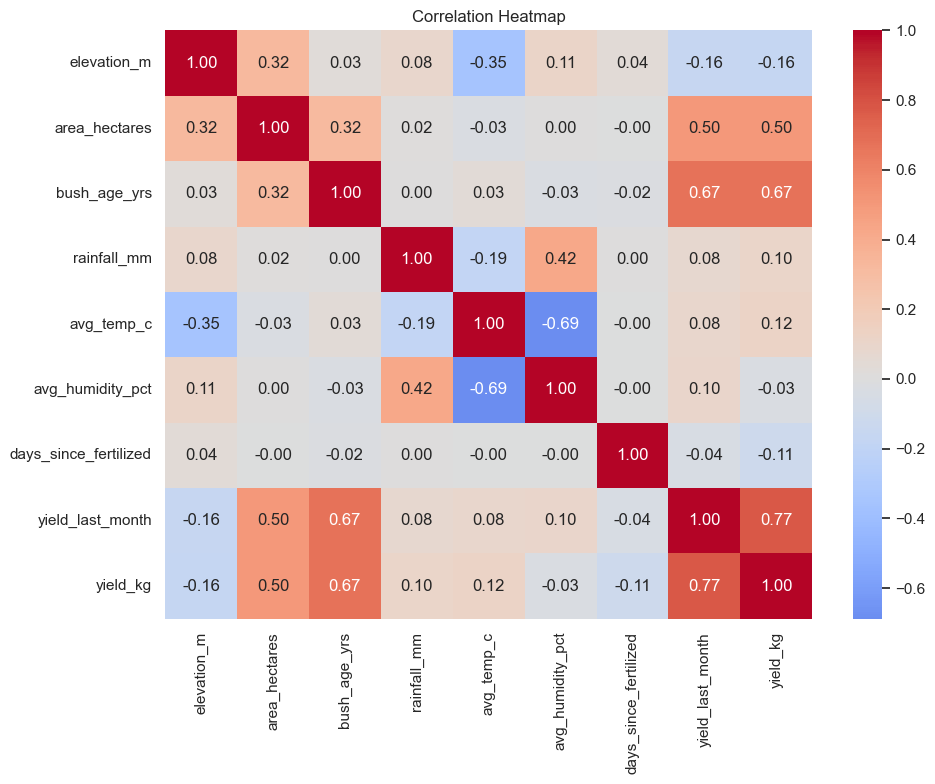

In [15]:
numeric_cols = ["elevation_m", "area_hectares", "bush_age_yrs",
                "rainfall_mm", "avg_temp_c", "avg_humidity_pct",
                "days_since_fertilized", "yield_last_month", "yield_kg"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

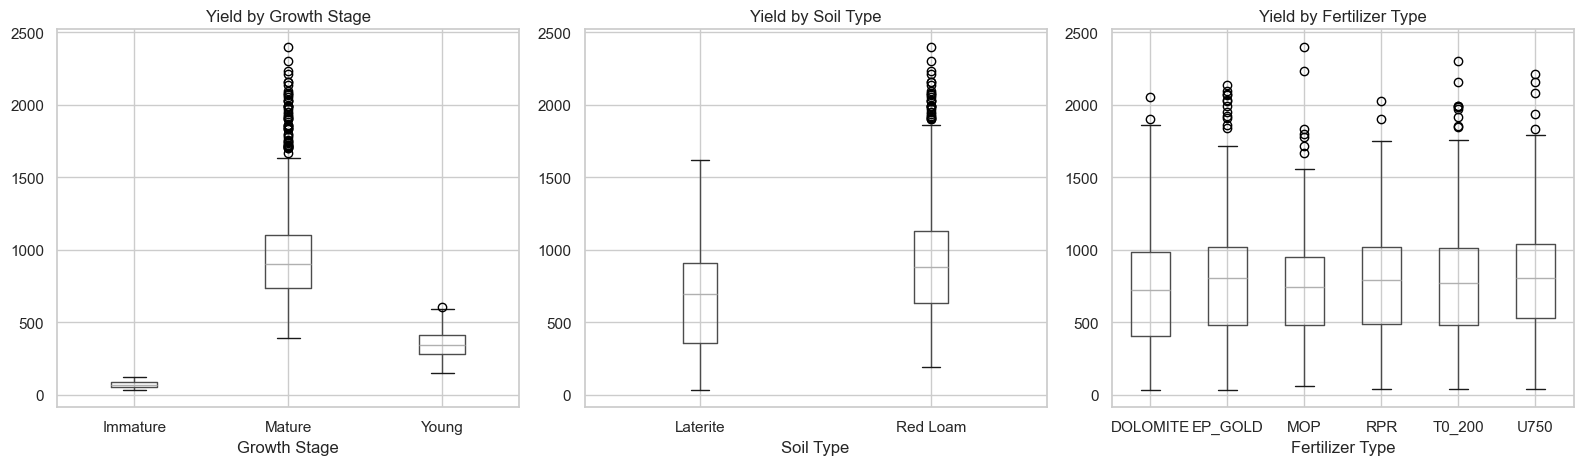

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

df.boxplot(column="yield_kg", by="growth_stage", ax=axes[0])
axes[0].set_title("Yield by Growth Stage")
axes[0].set_xlabel("Growth Stage")

df.boxplot(column="yield_kg", by="soil_type", ax=axes[1])
axes[1].set_title("Yield by Soil Type")
axes[1].set_xlabel("Soil Type")

df.boxplot(column="yield_kg", by="last_fertilizer_type", ax=axes[2])
axes[2].set_title("Yield by Fertilizer Type")
axes[2].set_xlabel("Fertilizer Type")

plt.suptitle("")
plt.tight_layout()
plt.show()

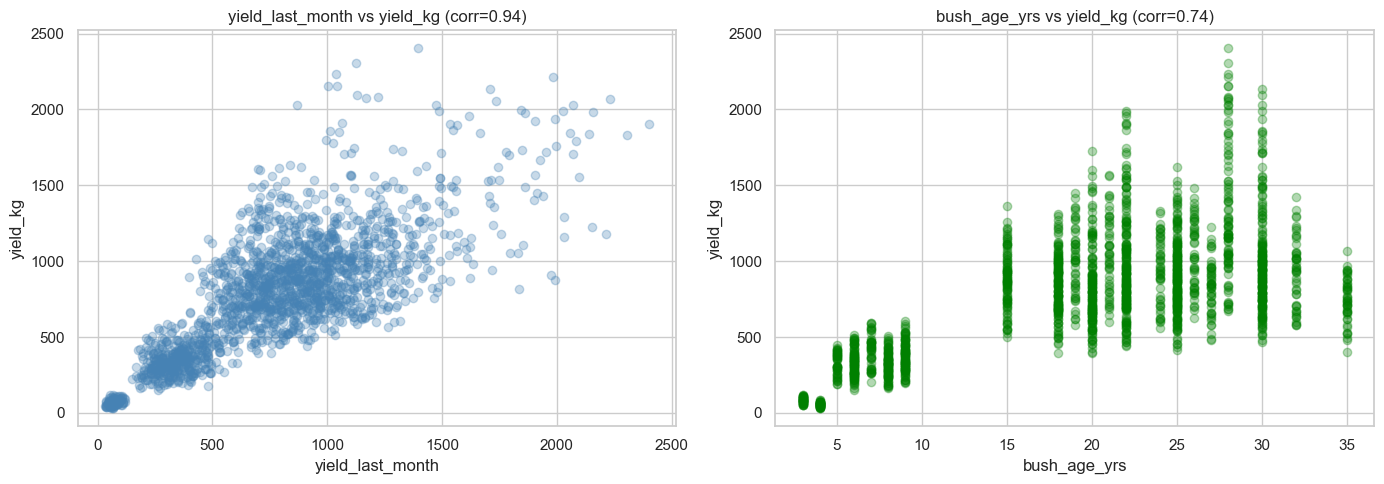

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["yield_last_month"], df["yield_kg"], alpha=0.3, color="steelblue")
axes[0].set_title("yield_last_month vs yield_kg (corr=0.94)")
axes[0].set_xlabel("yield_last_month")
axes[0].set_ylabel("yield_kg")

axes[1].scatter(df["bush_age_yrs"], df["yield_kg"], alpha=0.3, color="green")
axes[1].set_title("bush_age_yrs vs yield_kg (corr=0.74)")
axes[1].set_xlabel("bush_age_yrs")
axes[1].set_ylabel("yield_kg")

plt.tight_layout()
plt.show()

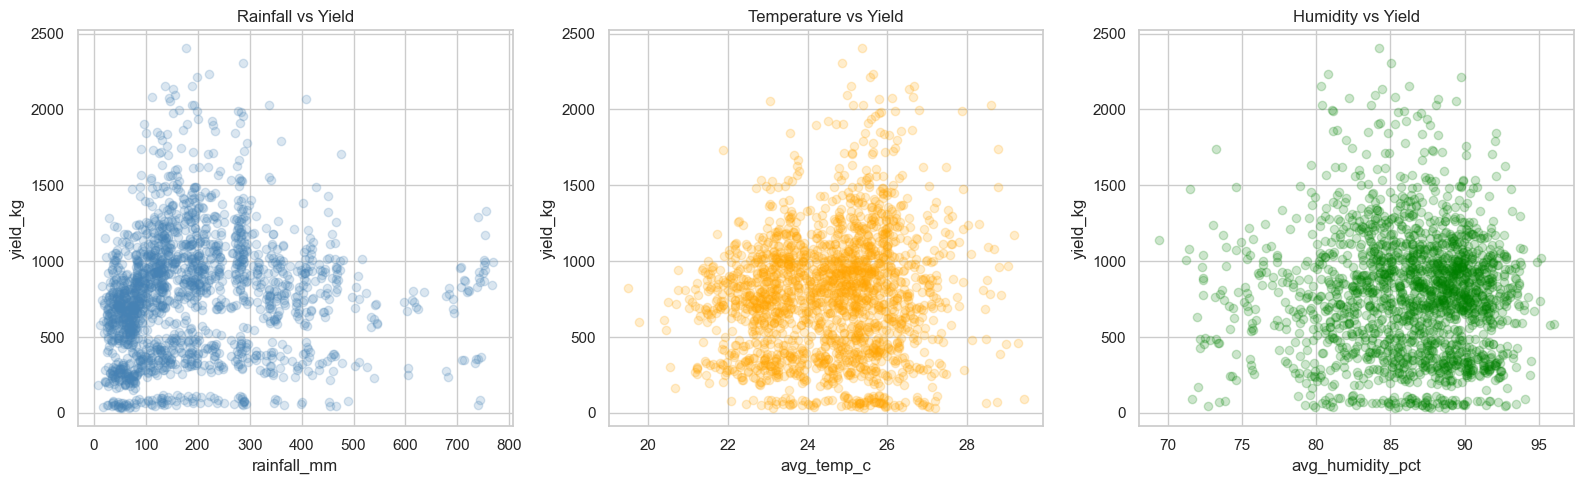

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Rainfall vs Yield
axes[0].scatter(df["rainfall_mm"], df["yield_kg"], alpha=0.2, color="steelblue")
axes[0].set_title("Rainfall vs Yield")
axes[0].set_xlabel("rainfall_mm")
axes[0].set_ylabel("yield_kg")

# Temperature vs Yield
axes[1].scatter(df["avg_temp_c"], df["yield_kg"], alpha=0.2, color="orange")
axes[1].set_title("Temperature vs Yield")
axes[1].set_xlabel("avg_temp_c")
axes[1].set_ylabel("yield_kg")

# Humidity vs Yield
axes[2].scatter(df["avg_humidity_pct"], df["yield_kg"], alpha=0.2, color="green")
axes[2].set_title("Humidity vs Yield")
axes[2].set_xlabel("avg_humidity_pct")
axes[2].set_ylabel("yield_kg")

plt.tight_layout()
plt.show()

In [19]:
print(df["rainfall_mm"].describe())
print(df["avg_temp_c"].describe())
print(df["avg_humidity_pct"].describe())

count    1872.000000
mean      189.079690
std       144.104751
min         7.370000
25%        81.152500
50%       144.550000
75%       272.470000
max       768.380000
Name: rainfall_mm, dtype: float64
count    1872.000000
mean       24.544193
std         1.556507
min        19.510000
25%        23.297500
50%        24.740000
75%        25.650000
max        29.410000
Name: avg_temp_c, dtype: float64
count    1872.000000
mean       86.361667
std         4.433762
min        69.410000
25%        83.760000
50%        87.055000
75%        89.642500
max        96.040000
Name: avg_humidity_pct, dtype: float64
